# SLoD Experiments

This notebook runs the full experiment pipeline without any interactive widgets. It loads the current dataset, regenerates embeddings only if needed, runs all probe experiments, and prints a compact analysis of the saved results.

In [1]:
from __future__ import annotations

import json
import os
import re
import sys
from pathlib import Path

# Resolve the repository root so the notebook works from any launch directory.
REPO_ROOT = None
for candidate in [Path.cwd().resolve(), *Path.cwd().resolve().parents]:
    if (candidate / "src").exists():
        REPO_ROOT = candidate
        break
if REPO_ROOT is None:
    raise RuntimeError("Could not locate the repository root")
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

# Put Matplotlib and fontconfig caches in a writable repo-local location.
cache_root = REPO_ROOT / ".cache" / "notebook"
mplconfigdir = cache_root / "matplotlib"
xdg_cache_home = cache_root / "xdg-cache"
mplconfigdir.mkdir(parents=True, exist_ok=True)
xdg_cache_home.mkdir(parents=True, exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", str(mplconfigdir))
os.environ.setdefault("XDG_CACHE_HOME", str(xdg_cache_home))

import matplotlib.pyplot as plt

from shared.utils import load_settings
from shared.schema import SpanRecord
from spans.balance import summarize_spans
from embed import build_embeddings
from probing.runner import run_probes

# Load the shared config once and reuse it for every downstream step.
settings = load_settings(REPO_ROOT / "config.toml")
spans_dir = REPO_ROOT / "data" / "spans"
embeddings_dir = REPO_ROOT / "embeddings"
results_dir = REPO_ROOT / "results"

# Toggle this to rebuild embeddings instead of reusing cached artifacts.
REGENERATE_EMBEDDINGS = False
CONTROL_STRATEGY = settings.pipeline.control_strategy
BATCH_SIZE = settings.pipeline.batch_size

# Quick sanity check that the notebook picked up the expected settings.
print("Repository root:", REPO_ROOT)
print("Models:", list(settings.embedding.model_name))
print("Domains:", list(settings.dataset.domains))


Repository root: /Users/shang/Development/slod-probe
Models: ['allenai/scibert_scivocab_uncased', 'BAAI/bge-small-en-v1.5']
Domains: ['nlp', 'cv']


In [2]:
# Read the generated span JSONL files back into typed records for summary stats.
def load_span_records(path: Path) -> list[SpanRecord]:
    records: list[SpanRecord] = []
    with path.open("r", encoding="utf-8") as handle:
        for line in handle:
            line = line.strip()
            if line:
                records.append(SpanRecord.model_validate_json(line))
    return records


# Summarize the saved spans before we touch embeddings or probes.
print("Span summaries")
for domain in settings.dataset.domains:
    path = spans_dir / f"{domain}.jsonl"
    summary = summarize_spans(load_span_records(path), target_domains=settings.dataset.domains)
    print(f"- {domain}: {json.dumps(summary, ensure_ascii=True)}")


Span summaries
- nlp: {"total_spans": 2805, "label_counts": {"macro": 935, "meso": 935, "micro": 935}, "domain_counts": {"nlp": 2805, "cv": 0}, "papers": 153}
- cv: {"total_spans": 3246, "label_counts": {"macro": 1082, "meso": 1082, "micro": 1082}, "domain_counts": {"nlp": 0, "cv": 3246}, "papers": 153}


In [3]:
# Match the slugging logic used by the embedding and probe code.
def slugify_model_name(model_name: str) -> str:
    slug = re.sub(r"[^a-zA-Z0-9]+", "_", model_name).strip("_")
    return slug.lower() or "model"


# Reuse cached embeddings unless a file is missing or regeneration is requested.
missing_artifacts: list[str] = []
for model_name in settings.embedding.model_name:
    model_dir = embeddings_dir / slugify_model_name(model_name)
    for domain in settings.dataset.domains:
        if not (model_dir / f"{domain}.pt").exists():
            missing_artifacts.append(f"{model_dir.name}/{domain}.pt")

# Build fresh embeddings only when needed.
if REGENERATE_EMBEDDINGS or missing_artifacts:
    if missing_artifacts and not REGENERATE_EMBEDDINGS:
        print("Missing embeddings detected; regenerating them now:")
        for artifact in missing_artifacts:
            print("-", artifact)
    outputs = build_embeddings(
        settings,
        spans_dir=spans_dir,
        output_dir=embeddings_dir,
        batch_size=BATCH_SIZE,
    )
    print("Embedding outputs:")
    for model_name, domain_outputs in outputs.items():
        print(f"- {model_name}")
        for domain, path in domain_outputs.items():
            print(f"  - {domain}: {path}")
else:
    print("Using existing embedding artifacts.")
    for model_name in settings.embedding.model_name:
        model_dir = embeddings_dir / slugify_model_name(model_name)
        print(f"- {model_name}")
        for domain in settings.dataset.domains:
            print(f"  - {domain}: {model_dir / f'{domain}.pt'}")


Using existing embedding artifacts.
- allenai/scibert_scivocab_uncased
  - nlp: /Users/shang/Development/slod-probe/embeddings/allenai_scibert_scivocab_uncased/nlp.pt
  - cv: /Users/shang/Development/slod-probe/embeddings/allenai_scibert_scivocab_uncased/cv.pt
- BAAI/bge-small-en-v1.5
  - nlp: /Users/shang/Development/slod-probe/embeddings/baai_bge_small_en_v1_5/nlp.pt
  - cv: /Users/shang/Development/slod-probe/embeddings/baai_bge_small_en_v1_5/cv.pt


In [4]:
# Run the full experiment matrix and persist the metrics to results/.
payload = run_probes(
    settings,
    embeddings_dir=embeddings_dir,
    results_dir=results_dir,
    batch_size=BATCH_SIZE,
    control_strategy=CONTROL_STRATEGY,
)
results_path = Path(payload["results_path"])
print("Results written to:", results_path)
print("Runs:", len(payload["runs"]))


probing model allenai/scibert_scivocab_uncased -> allenai_scibert_scivocab_uncased
  in-domain nlp
  in-domain cv
  cross-domain nlp -> cv
  cross-domain cv -> nlp
  controlled in-domain nlp
  controlled in-domain cv
probing model BAAI/bge-small-en-v1.5 -> baai_bge_small_en_v1_5
  in-domain nlp
  in-domain cv
  cross-domain nlp -> cv
  cross-domain cv -> nlp
  controlled in-domain nlp
  controlled in-domain cv
Results written to: /Users/shang/Development/slod-probe/results/probe_results.json
Runs: 12


In [5]:
# Format the saved metrics into a compact text table for the notebook output.
def format_table(rows: list[list[str]]) -> str:
    widths = [max(len(str(row[i])) for row in rows) for i in range(len(rows[0]))]
    lines = []
    for row_index, row in enumerate(rows):
        line = " | ".join(str(value).ljust(widths[i]) for i, value in enumerate(row))
        lines.append(line)
        if row_index == 0:
            lines.append("-+-".join("-" * width for width in widths))
    return "\n".join(lines)


# Use the nested probe/baseline metrics emitted by src.probe.
runs = payload["runs"]
rows = [["model", "condition", "train", "test", "probe_f1", "probe_acc", "base_f1"]]
for run in runs:
    probe = run["probe"]
    baseline = run["baseline"]
    rows.append([
        run["model_slug"],
        run["condition"],
        run["train_domain"],
        run["test_domain"],
        f"{probe['macro_f1']:.3f}",
        f"{probe['accuracy']:.3f}",
        f"{baseline['macro_f1']:.3f}",
    ])
print(format_table(rows))


model                            | condition    | train | test | probe_f1 | probe_acc | base_f1
---------------------------------+--------------+-------+------+----------+-----------+--------
allenai_scibert_scivocab_uncased | in_domain    | nlp   | nlp  | 0.612    | 0.613     | 0.147  
allenai_scibert_scivocab_uncased | in_domain    | cv    | cv   | 0.656    | 0.658     | 0.153  
allenai_scibert_scivocab_uncased | cross_domain | nlp   | cv   | 0.600    | 0.598     | 0.167  
allenai_scibert_scivocab_uncased | cross_domain | cv    | nlp  | 0.582    | 0.582     | 0.167  
allenai_scibert_scivocab_uncased | controlled   | nlp   | nlp  | 0.601    | 0.602     | 0.147  
allenai_scibert_scivocab_uncased | controlled   | cv    | cv   | 0.597    | 0.597     | 0.153  
baai_bge_small_en_v1_5           | in_domain    | nlp   | nlp  | 0.589    | 0.591     | 0.147  
baai_bge_small_en_v1_5           | in_domain    | cv    | cv   | 0.582    | 0.585     | 0.153  
baai_bge_small_en_v1_5           | cross

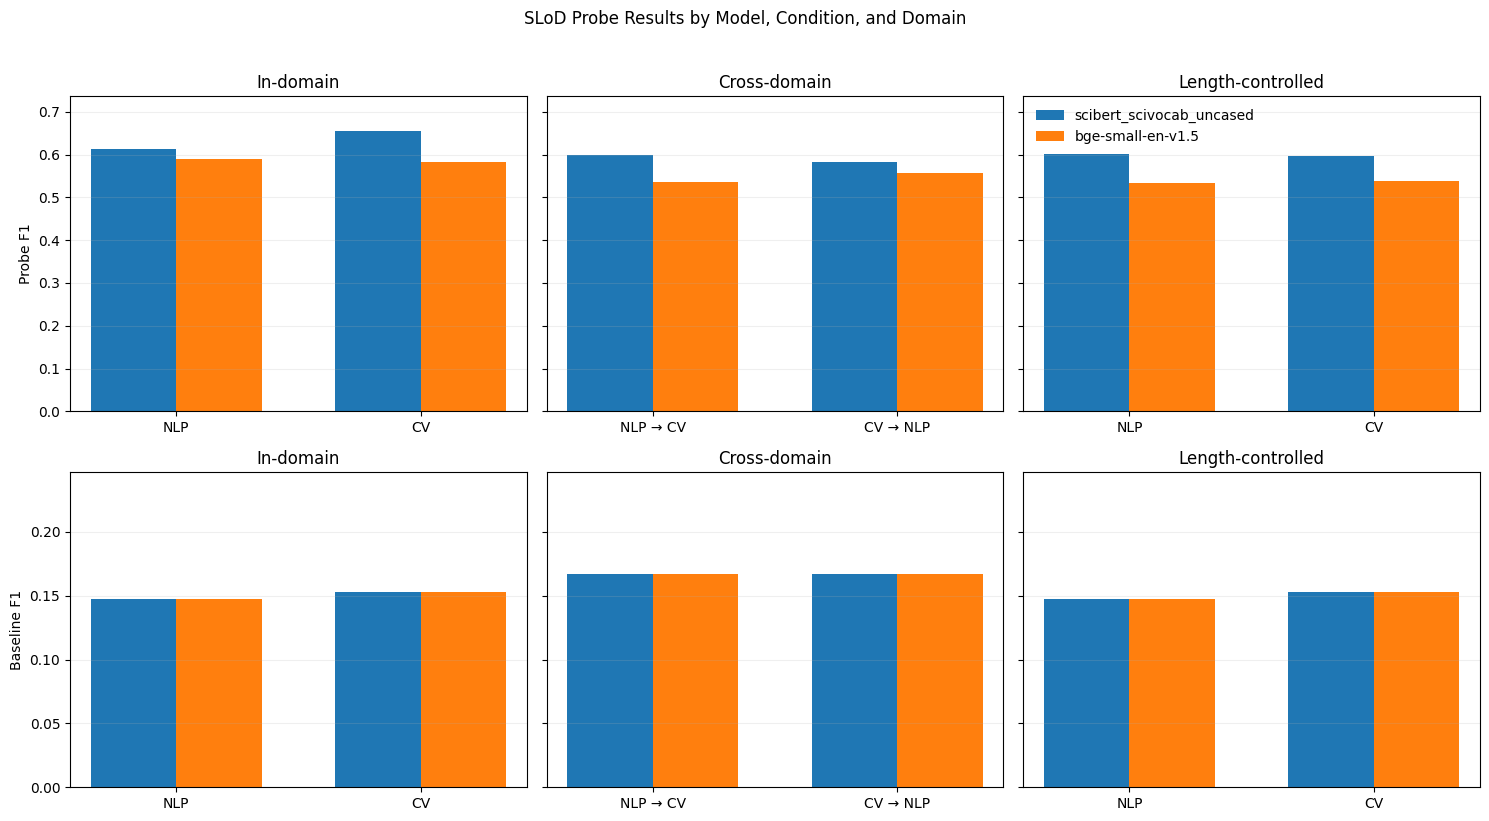

Saved plot to: /Users/shang/Development/slod-probe/results/probe_results.png


In [6]:
# Build the main figure: macro F1 for probe vs. majority baseline.
condition_order = ["in_domain", "cross_domain", "controlled"]
condition_titles = {
    "in_domain": "In-domain",
    "cross_domain": "Cross-domain",
    "controlled": "Length-controlled",
}
condition_categories = {
    "in_domain": [(domain, domain) for domain in settings.dataset.domains],
    "cross_domain": [(settings.dataset.domains[0], settings.dataset.domains[1]), (settings.dataset.domains[1], settings.dataset.domains[0])],
    "controlled": [(domain, domain) for domain in settings.dataset.domains],
}
category_labels = {
    (settings.dataset.domains[0], settings.dataset.domains[0]): settings.dataset.domains[0].upper(),
    (settings.dataset.domains[1], settings.dataset.domains[1]): settings.dataset.domains[1].upper(),
    (settings.dataset.domains[0], settings.dataset.domains[1]): f"{settings.dataset.domains[0].upper()} → {settings.dataset.domains[1].upper()}",
    (settings.dataset.domains[1], settings.dataset.domains[0]): f"{settings.dataset.domains[1].upper()} → {settings.dataset.domains[0].upper()}",
}
model_names = list(settings.embedding.model_name)
model_slugs = [slugify_model_name(model_name) for model_name in model_names]
model_labels = dict(zip(model_slugs, [name.split("/")[-1] for name in model_names], strict=True))
by_key = {
    (run["model_slug"], run["condition"], run["train_domain"], run["test_domain"]): run
    for run in runs
}

figure, axes = plt.subplots(2, len(condition_order), figsize=(15, 8), sharey="row")
bar_width = 0.35 if len(model_slugs) == 2 else 0.8 / max(1, len(model_slugs))
probe_max = max(run["probe"]["macro_f1"] for run in runs)
baseline_max = max(run["baseline"]["macro_f1"] for run in runs)

for col, condition in enumerate(condition_order):
    for row, metric_name in enumerate(["probe", "baseline"]):
        ax = axes[row][col]
        categories = condition_categories[condition]
        x_positions = list(range(len(categories)))
        for model_index, model_slug in enumerate(model_slugs):
            offset = (model_index - (len(model_slugs) - 1) / 2) * bar_width
            values = []
            for train_domain, test_domain in categories:
                run = by_key[(model_slug, condition, train_domain, test_domain)]
                values.append(run[metric_name]["macro_f1"])
            ax.bar(
                [x + offset for x in x_positions],
                values,
                width=bar_width,
                label=model_labels[model_slug] if row == 0 else None,
            )
        ax.set_title(condition_titles[condition])
        ax.set_xticks(x_positions)
        ax.set_xticklabels([category_labels[category] for category in categories])
        ax.grid(axis="y", alpha=0.2)
        if col == 0:
            ax.set_ylabel("Probe F1" if row == 0 else "Baseline F1")
        ax.set_ylim(0.0, max(probe_max, baseline_max) + 0.08 if row == 0 else baseline_max + 0.08)
        if row == 0 and col == len(condition_order) - 1:
            ax.legend(frameon=False, loc="upper left")

figure.suptitle("SLoD Probe Results by Model, Condition, and Domain", y=1.02)
figure.tight_layout()
plot_path = results_dir / "probe_results.png"
results_dir.mkdir(parents=True, exist_ok=True)
figure.savefig(plot_path, dpi=200, bbox_inches="tight")
plt.show()
print("Saved plot to:", plot_path)


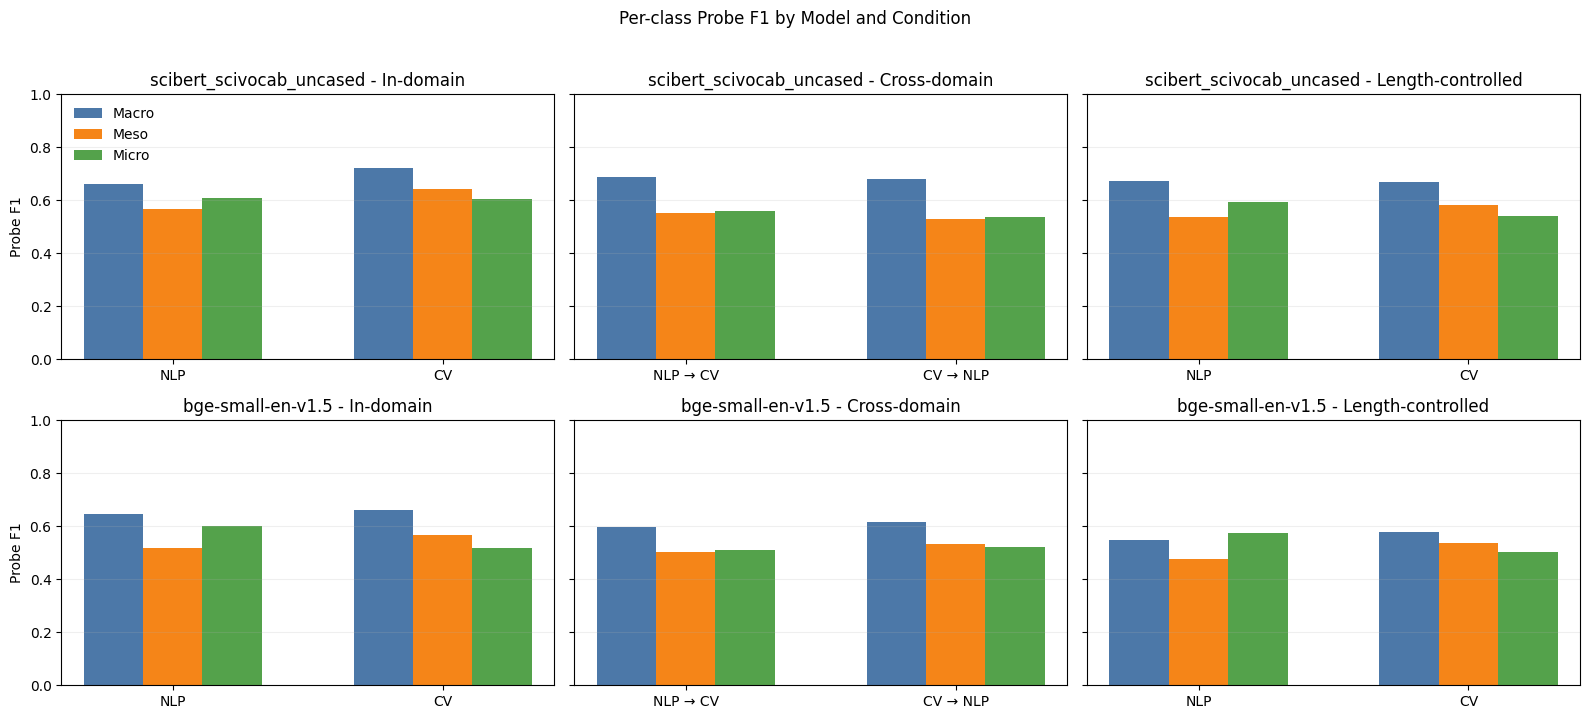

Saved class plot to: /Users/shang/Development/slod-probe/results/probe_class_f1.png


In [7]:
# Build the supporting figure: per-class probe F1.
class_labels = ["macro", "meso", "micro"]
class_bar_colors = ["#4C78A8", "#F58518", "#54A24B"]

figure2, axes2 = plt.subplots(len(model_slugs), len(condition_order), figsize=(16, 7), sharey=True)
class_bar_width = 0.22

for row, model_slug in enumerate(model_slugs):
    for col, condition in enumerate(condition_order):
        ax = axes2[row][col]
        categories = condition_categories[condition]
        x_positions = list(range(len(categories)))
        for class_index, class_label in enumerate(class_labels):
            offset = (class_index - (len(class_labels) - 1) / 2) * class_bar_width
            values = []
            for train_domain, test_domain in categories:
                run = by_key[(model_slug, condition, train_domain, test_domain)]
                values.append(run["probe"]["per_class"][class_label]["f1"])
            ax.bar(
                [x + offset for x in x_positions],
                values,
                width=class_bar_width,
                color=class_bar_colors[class_index],
                label=class_label.capitalize() if row == 0 and col == 0 else None,
            )
        ax.set_ylim(0.0, 1.0)
        ax.set_title(f"{model_labels[model_slug]} - {condition_titles[condition]}")
        ax.set_xticks(x_positions)
        ax.set_xticklabels([category_labels[category] for category in categories])
        ax.grid(axis="y", alpha=0.2)
        if col == 0:
            ax.set_ylabel("Probe F1")
        if row == 0 and col == 0:
            ax.legend(frameon=False, loc="upper left")

figure2.suptitle("Per-class Probe F1 by Model and Condition", y=1.02)
figure2.tight_layout()
class_plot_path = results_dir / "probe_class_f1.png"
figure2.savefig(class_plot_path, dpi=200, bbox_inches="tight")
plt.show()
print("Saved class plot to:", class_plot_path)


In [8]:
by_key = {
    (run["model_slug"], run["condition"], run["train_domain"], run["test_domain"]): run
    for run in runs
}

print("Takeaways")
for model_name in settings.embedding.model_name:
    model_slug = slugify_model_name(model_name)
    print(f"{model_name} ({model_slug})")
    for domain in settings.dataset.domains:
        in_domain = by_key[(model_slug, "in_domain", domain, domain)]
        controlled = by_key[(model_slug, "controlled", domain, domain)]
        in_probe = in_domain["probe"]
        controlled_probe = controlled["probe"]
        print(
            f"- {domain}: in-domain macro F1 {in_probe['macro_f1']:.3f}, "
            f"controlled macro F1 {controlled_probe['macro_f1']:.3f}, "
            f"cross-domain best {max(
                run['probe']['macro_f1']
                for run in runs
                if run['model_slug'] == model_slug and run['condition'] == 'cross_domain' and run['train_domain'] == domain
            ):.3f}"
        )

print("\nSaved results:", results_path)


Takeaways
allenai/scibert_scivocab_uncased (allenai_scibert_scivocab_uncased)
- nlp: in-domain macro F1 0.612, controlled macro F1 0.601, cross-domain best 0.600
- cv: in-domain macro F1 0.656, controlled macro F1 0.597, cross-domain best 0.582
BAAI/bge-small-en-v1.5 (baai_bge_small_en_v1_5)
- nlp: in-domain macro F1 0.589, controlled macro F1 0.533, cross-domain best 0.536
- cv: in-domain macro F1 0.582, controlled macro F1 0.538, cross-domain best 0.557

Saved results: /Users/shang/Development/slod-probe/results/probe_results.json
